# LASSO Feature Selection Timeline By Month

Batch visualization for **all crops** and **all horizons** using HAR **LASSO expanding** checkpoints for the full feature set `har_endo_exo_climate_news_macro`.

The notebook:
- scans benchmark outputs under `data/benchmark/*/har/mean`
- keeps only `model_type == lasso_expanding`
- keeps only `feature_set == har_endo_exo_climate_news_macro`
- skips crop / horizon combinations where that run does not exist
- aggregates daily selections to **monthly** chosen/not-chosen status
- plots a heatmap for each available crop/horizon run
- saves plots as `.png` files


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

BENCHMARK_ROOT = PROJECT_ROOT / 'data' / 'benchmark'
OUTPUT_ROOT = BENCHMARK_ROOT / 'plots' / 'feature_selection_monthly'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Benchmark root: {BENCHMARK_ROOT}')
print(f'Output root: {OUTPUT_ROOT}')


Project root: /Users/arshia/Projects/Papers/FinancialAI/Volf
Benchmark root: /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark
Output root: /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark/plots/feature_selection_monthly


In [3]:
def safe_name(value: str) -> str:
    cleaned = re.sub(r'[^A-Za-z0-9._-]+', '_', str(value).strip())
    return cleaned.strip('_') or 'unknown'


def discover_har_summaries(benchmark_root: Path) -> pd.DataFrame:
    rows: list[dict] = []
    for csv_path in sorted(benchmark_root.glob('*/har/mean/target_horizon_*/har.csv')):
        crop = csv_path.parts[-5]
        horizon = int(csv_path.parent.name.split('_')[-1])
        frame = pd.read_csv(csv_path)
        if frame.empty:
            continue
        frame = frame.copy()
        frame['crop'] = crop
        frame['target_horizon'] = frame.get('target_horizon', horizon)
        frame['summary_path'] = str(csv_path)
        rows.extend(frame.to_dict(orient='records'))

    if not rows:
        raise FileNotFoundError(f'No HAR summary files found under {benchmark_root}')
    out = pd.DataFrame(rows)
    out['target_horizon'] = out['target_horizon'].astype(int)
    return out


summary_df = discover_har_summaries(BENCHMARK_ROOT)
TARGET_MODEL_TYPE = 'lasso_expanding'
TARGET_FEATURE_SET = 'har_endo_exo_climate_news_macro'

lasso_runs_df = (
    summary_df.loc[
        summary_df['model_type'].astype(str).eq(TARGET_MODEL_TYPE)
        & summary_df['feature_set'].astype(str).eq(TARGET_FEATURE_SET)
    ]
    .sort_values(['crop', 'target_horizon', 'test_r2'], ascending=[True, True, False])
    .reset_index(drop=True)
)

print(f'Total HAR rows: {len(summary_df):,}')
print(f'Matching LASSO expanding rows: {len(lasso_runs_df):,}')
display(lasso_runs_df[['crop', 'target_horizon', 'model_type', 'feature_set', 'test_r2', 'n_selected']].head(20))


Total HAR rows: 900
Matching LASSO expanding rows: 15


,crop,target_horizon,model_type,feature_set,test_r2,n_selected
0,corn,1,lasso_expanding,har_endo_exo_climate_news_macro,0.516621,37
1,corn,4,lasso_expanding,har_endo_exo_climate_news_macro,0.535164,40
2,corn,8,lasso_expanding,har_endo_exo_climate_news_macro,0.422695,44
3,corn,12,lasso_expanding,har_endo_exo_climate_news_macro,0.372884,46
4,corn,16,lasso_expanding,har_endo_exo_climate_news_macro,0.306955,46
5,soybean,1,lasso_expanding,har_endo_exo_climate_news_macro,0.547007,25
6,soybean,4,lasso_expanding,har_endo_exo_climate_news_macro,0.532868,30
7,soybean,8,lasso_expanding,har_endo_exo_climate_news_macro,0.444033,31
8,soybean,12,lasso_expanding,har_endo_exo_climate_news_macro,0.325476,37
9,soybean,16,lasso_expanding,har_endo_exo_climate_news_macro,0.268160,41


In [4]:
def checkpoint_dir_from_row(benchmark_root: Path, row: pd.Series) -> Path:
    return (
        benchmark_root
        / str(row['crop'])
        / 'har'
        / 'mean'
        / f"target_horizon_{int(row['target_horizon'])}"
        / 'checkpoints'
        / f"{safe_name(row['model_type'])}__{safe_name(row['feature_set'])}"
    )


def load_selection_artifacts(benchmark_root: Path, row: pd.Series) -> tuple[Path, pd.DataFrame, dict]:
    ckpt_dir = checkpoint_dir_from_row(benchmark_root, row)
    per_window_path = ckpt_dir / 'per_window_selection.csv'
    selection_info_path = ckpt_dir / 'selection_info.json'

    if not per_window_path.exists():
        raise FileNotFoundError(f'Missing file: {per_window_path}')

    per_window_df = pd.read_csv(per_window_path)
    selection_info = {}
    if selection_info_path.exists():
        selection_info = json.loads(selection_info_path.read_text(encoding='utf-8'))

    return ckpt_dir, per_window_df, selection_info


In [5]:
def explode_selection_by_day(per_window_df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict] = []

    for row in per_window_df.to_dict(orient='records'):
        selected_feature = row.get('selected_feature')
        if pd.isna(selected_feature):
            continue

        raw_test_dates = row.get('test_dates')
        if isinstance(raw_test_dates, str) and raw_test_dates.strip():
            dates = [pd.to_datetime(item) for item in raw_test_dates.split('|') if item]
        else:
            fallback = row.get('test_start_date') or row.get('test_end_date')
            dates = [pd.to_datetime(fallback)] if pd.notna(fallback) else []

        for date in dates:
            rows.append(
                {
                    'date': pd.to_datetime(date).normalize(),
                    'feature': str(selected_feature),
                    'window_id': int(row['window_id']),
                    'selected': 1,
                    'selection_method': row.get('selection_method'),
                    'selection_reused': bool(row.get('selection_reused', False)),
                }
            )

    if not rows:
        raise ValueError('Could not create any daily feature-selection rows.')

    chosen_df = pd.DataFrame(rows).drop_duplicates(subset=['date', 'feature'], keep='last')
    all_dates = pd.Index(sorted(chosen_df['date'].unique()), name='date')
    all_features = pd.Index(sorted(chosen_df['feature'].unique()), name='feature')
    dense_index = pd.MultiIndex.from_product([all_dates, all_features], names=['date', 'feature'])

    dense_df = (
        chosen_df.set_index(['date', 'feature'])[['selected', 'window_id', 'selection_method', 'selection_reused']]
        .reindex(dense_index)
        .reset_index()
    )
    dense_df['selected'] = dense_df['selected'].fillna(0).astype(int)
    dense_df['month'] = dense_df['date'].dt.to_period('M').dt.to_timestamp()
    dense_df['chosen_label'] = dense_df['selected'].map({1: 'chosen', 0: 'not chosen'})
    return dense_df.sort_values(['feature', 'date']).reset_index(drop=True)


def aggregate_selection_by_month(selection_daily_df: pd.DataFrame) -> pd.DataFrame:
    monthly_df = (
        selection_daily_df.groupby(['month', 'feature'], as_index=False)
        .agg(
            selected_days=('selected', 'sum'),
            total_days=('selected', 'size'),
            reused_any=('selection_reused', 'max'),
        )
    )
    monthly_df['selected_share'] = monthly_df['selected_days'] / monthly_df['total_days']
    monthly_df['selected'] = (monthly_df['selected_days'] > 0).astype(int)
    monthly_df['chosen_label'] = monthly_df['selected'].map({1: 'chosen', 0: 'not chosen'})
    return monthly_df.sort_values(['feature', 'month']).reset_index(drop=True)


In [6]:
def plot_monthly_feature_selection(
    monthly_df: pd.DataFrame,
    *,
    title: str,
    output_path: Path | None = None,
    top_n_features: int | None = None,
) -> pd.DataFrame:
    plot_df = monthly_df.copy()

    feature_order = (
        plot_df.groupby('feature', as_index=False)['selected_share']
        .mean()
        .sort_values(['selected_share', 'feature'], ascending=[False, True])
    )
    if top_n_features is not None:
        keep = feature_order.head(top_n_features)['feature']
        plot_df = plot_df.loc[plot_df['feature'].isin(keep)].copy()
        feature_order = feature_order.head(top_n_features)

    ordered_features = feature_order['feature'].tolist()
    heatmap_df = (
        plot_df.pivot(index='feature', columns='month', values='selected')
        .reindex(ordered_features)
        .sort_index(axis=1)
    )

    fig_width = max(12, heatmap_df.shape[1] * 0.8)
    fig_height = max(5, heatmap_df.shape[0] * 0.42)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(
        heatmap_df,
        cmap=sns.color_palette(['#d62728', '#2ca02c']),
        vmin=0,
        vmax=1,
        cbar=True,
        linewidths=0.05,
        linecolor='lightgray',
        ax=ax,
    )
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticks([0.25, 0.75])
    colorbar.set_ticklabels(['not chosen', 'chosen'])
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Month')
    ax.set_ylabel('Feature')
    ax.set_xticklabels([pd.Timestamp(col).strftime('%Y-%m') for col in heatmap_df.columns], rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()

    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=200, bbox_inches='tight')

    plt.show()
    plt.close(fig)
    return heatmap_df


## Batch export settings

In [7]:
SAVE_PLOTS = True
TOP_N_FEATURES = None

runs_to_process = lasso_runs_df.copy()

print(f'Runs to process: {len(runs_to_process):,}')
display(runs_to_process[['crop', 'target_horizon', 'model_type', 'feature_set', 'test_r2']].head(20))


Runs to process: 15


,crop,target_horizon,model_type,feature_set,test_r2
0,corn,1,lasso_expanding,har_endo_exo_climate_news_macro,0.516621
1,corn,4,lasso_expanding,har_endo_exo_climate_news_macro,0.535164
2,corn,8,lasso_expanding,har_endo_exo_climate_news_macro,0.422695
3,corn,12,lasso_expanding,har_endo_exo_climate_news_macro,0.372884
4,corn,16,lasso_expanding,har_endo_exo_climate_news_macro,0.306955
5,soybean,1,lasso_expanding,har_endo_exo_climate_news_macro,0.547007
6,soybean,4,lasso_expanding,har_endo_exo_climate_news_macro,0.532868
7,soybean,8,lasso_expanding,har_endo_exo_climate_news_macro,0.444033
8,soybean,12,lasso_expanding,har_endo_exo_climate_news_macro,0.325476
9,soybean,16,lasso_expanding,har_endo_exo_climate_news_macro,0.268160


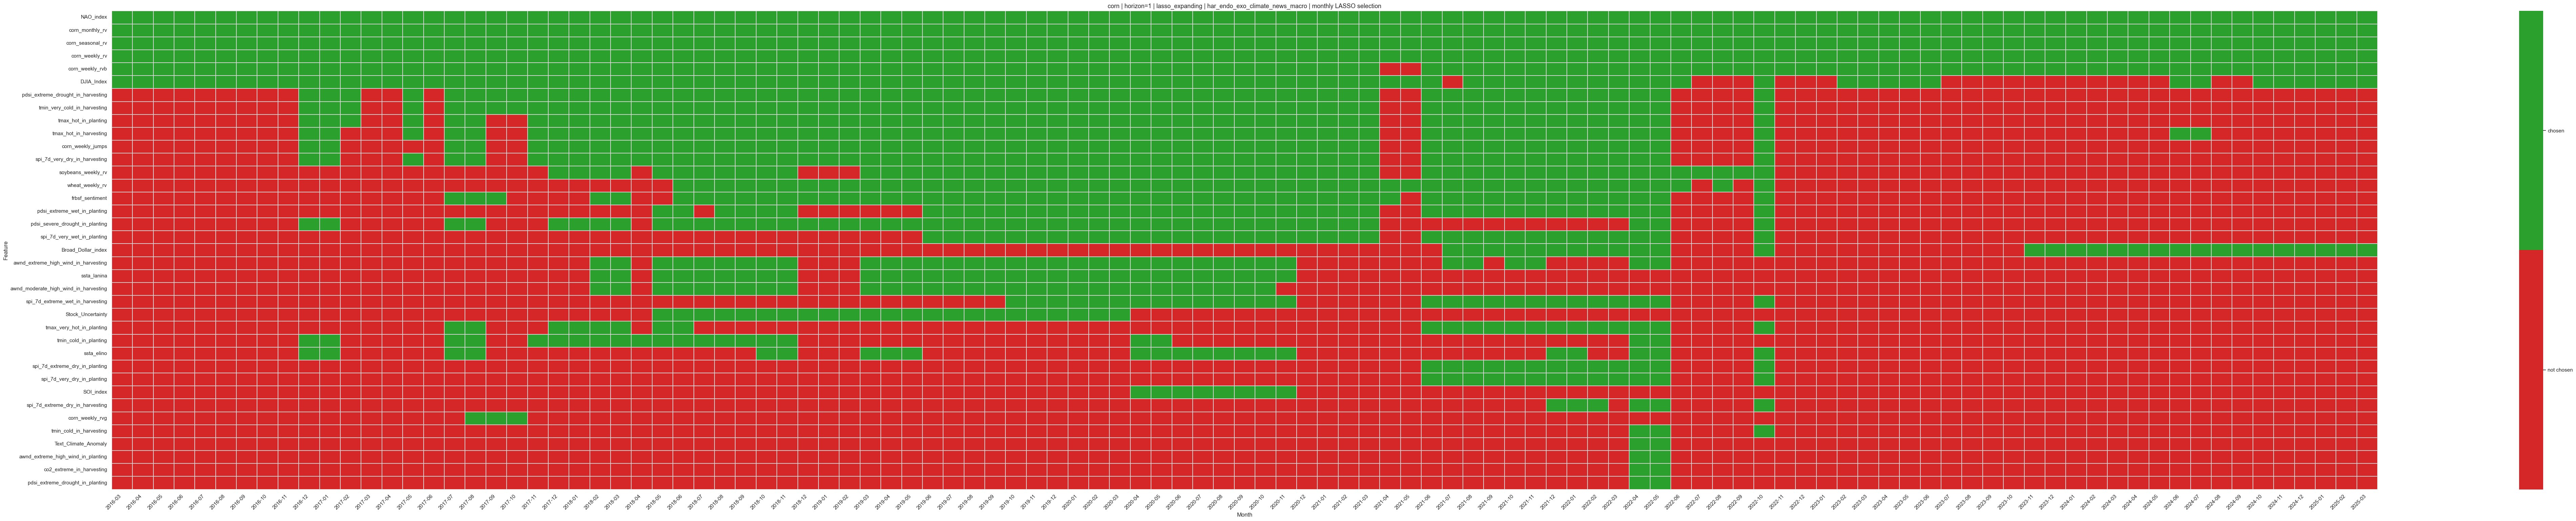

,feature,selected_months,total_months,average_selected_share
0,NAO_index,109,109,1.000000
1,corn_monthly_rv,109,109,1.000000
2,corn_seasonal_rv,109,109,1.000000
3,corn_weekly_rv,109,109,1.000000
4,corn_weekly_rvb,107,109,0.981651
5,DJIA_Index,89,109,0.779664
6,pdsi_extreme_drought_in_harvesting,62,109,0.553823
7,tmin_very_cold_in_harvesting,62,109,0.553823
8,tmax_hot_in_planting,60,109,0.533180
9,tmax_hot_in_harvesting,61,109,0.528746


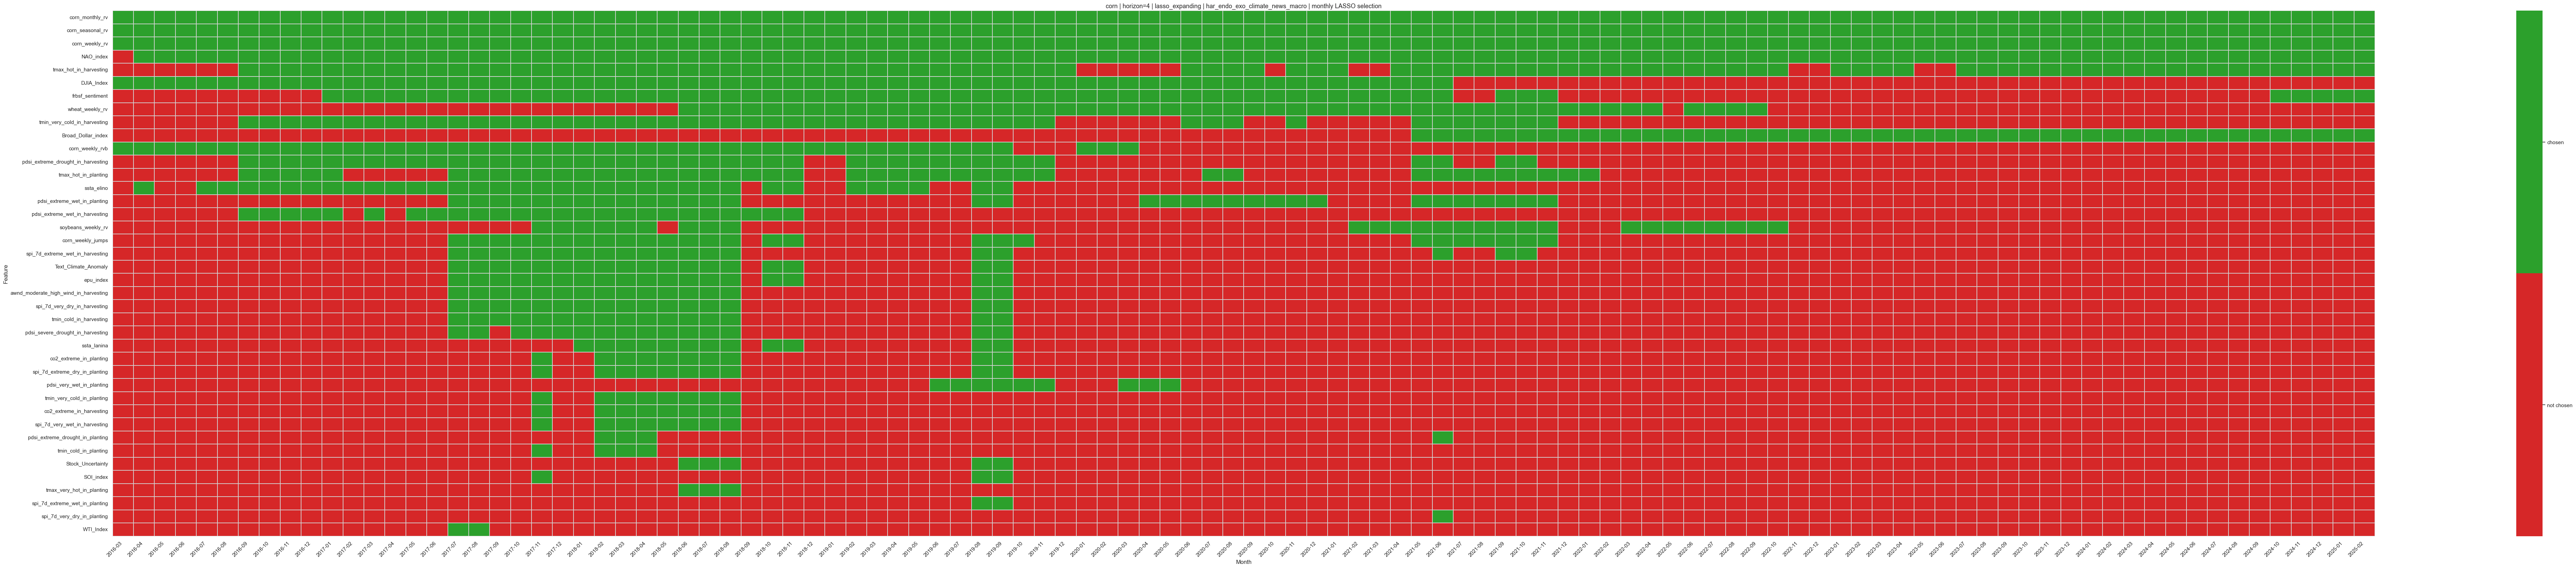

,feature,selected_months,total_months,average_selected_share
0,corn_monthly_rv,108,108,1.000000
1,corn_seasonal_rv,108,108,1.000000
2,corn_weekly_rv,108,108,1.000000
3,NAO_index,107,108,0.990741
4,tmax_hot_in_harvesting,90,108,0.813735
5,DJIA_Index,64,108,0.592593
6,frbsf_sentiment,62,108,0.548765
7,wheat_weekly_rv,51,108,0.454475
8,tmin_very_cold_in_harvesting,50,108,0.439969
9,Broad_Dollar_index,46,108,0.411111


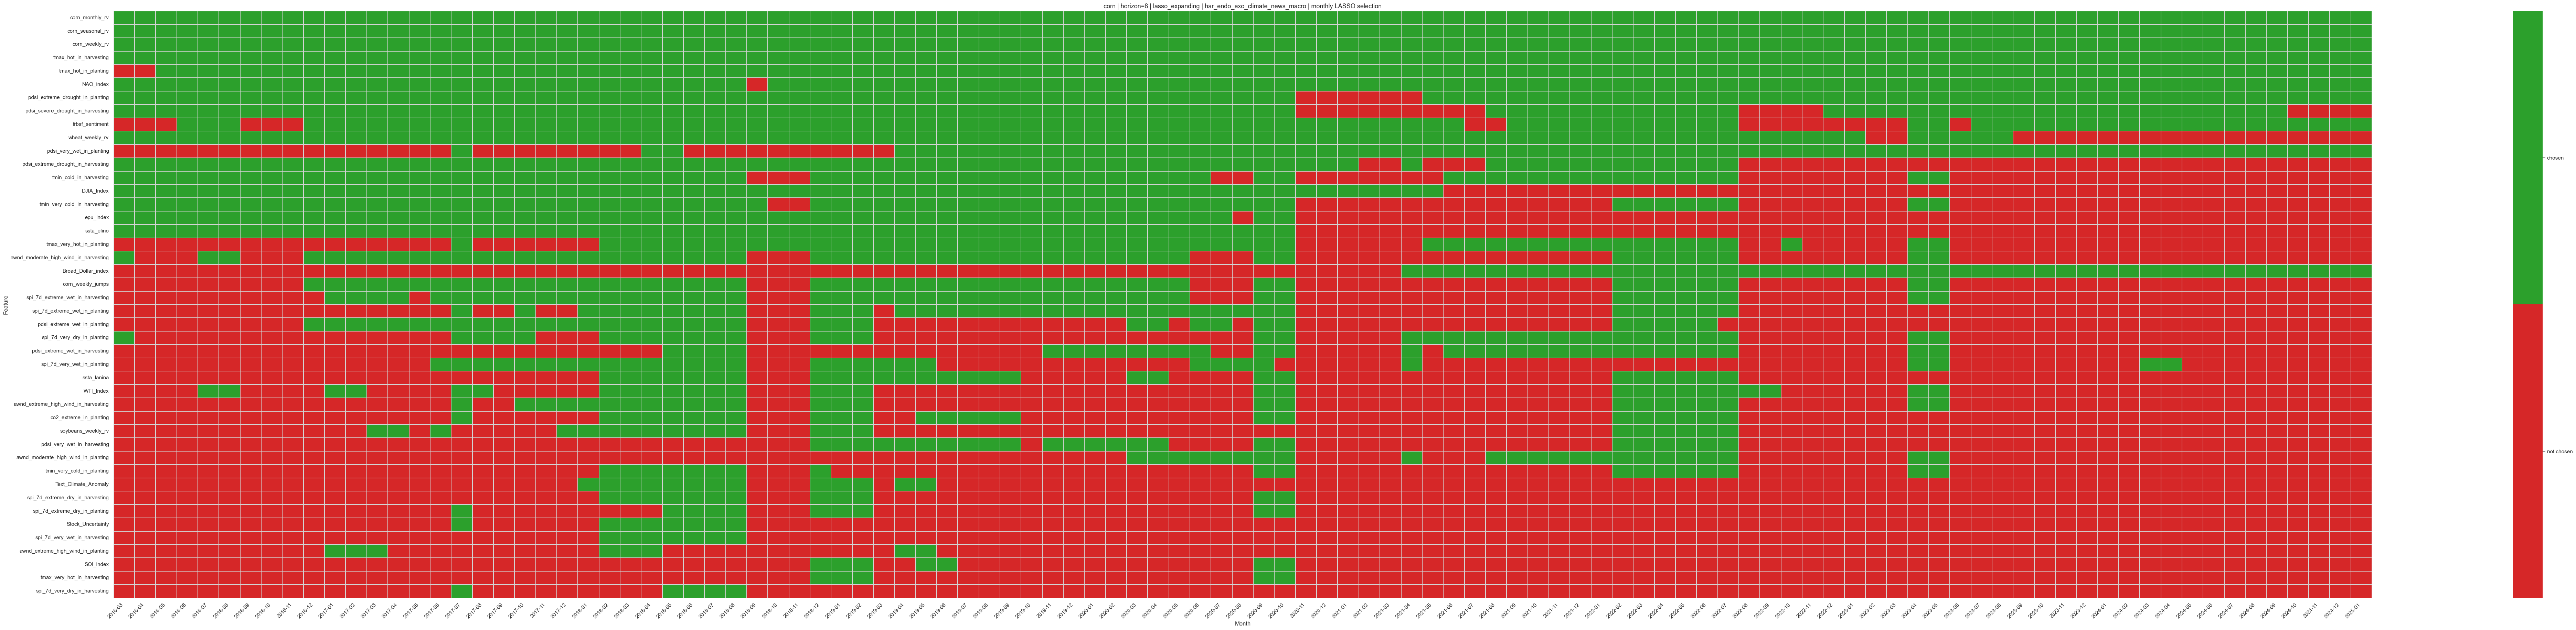

,feature,selected_months,total_months,average_selected_share
0,corn_monthly_rv,107,107,1.000000
1,corn_seasonal_rv,107,107,1.000000
2,corn_weekly_rv,107,107,1.000000
3,tmax_hot_in_harvesting,107,107,1.000000
4,tmax_hot_in_planting,105,107,0.981308
5,NAO_index,106,107,0.968069
6,pdsi_extreme_drought_in_planting,101,107,0.933956
7,pdsi_severe_drought_in_harvesting,90,107,0.824611
8,frbsf_sentiment,90,107,0.811215
9,wheat_weekly_rv,88,107,0.806854


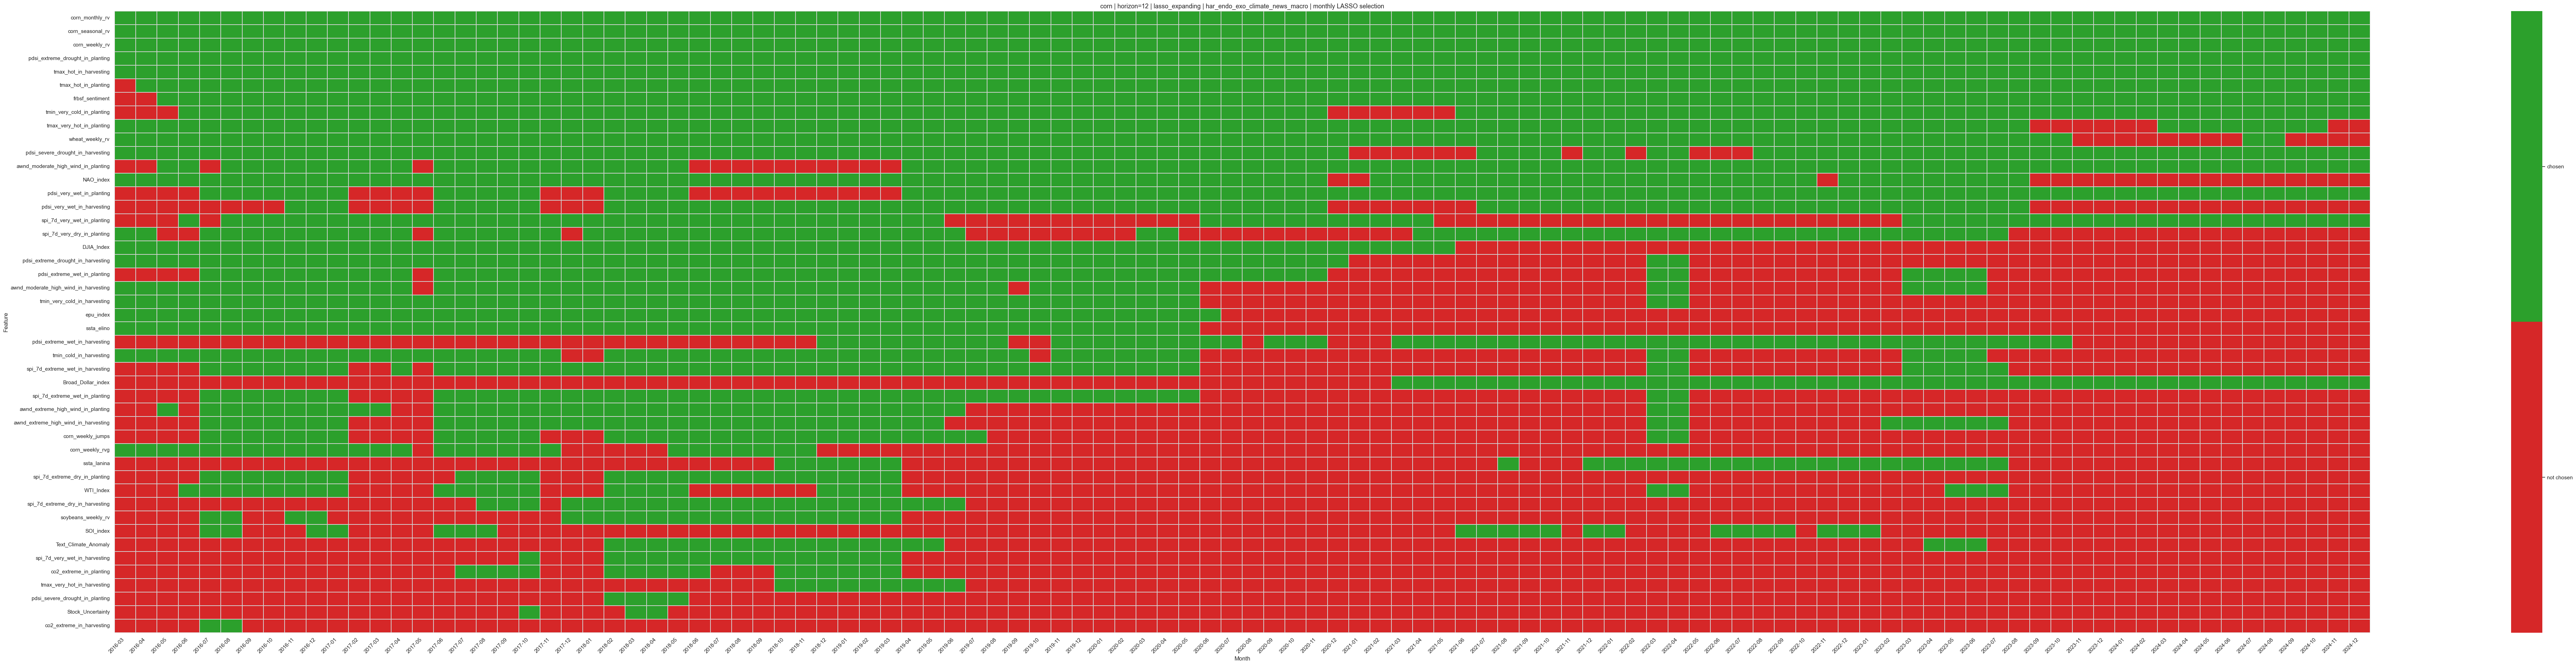

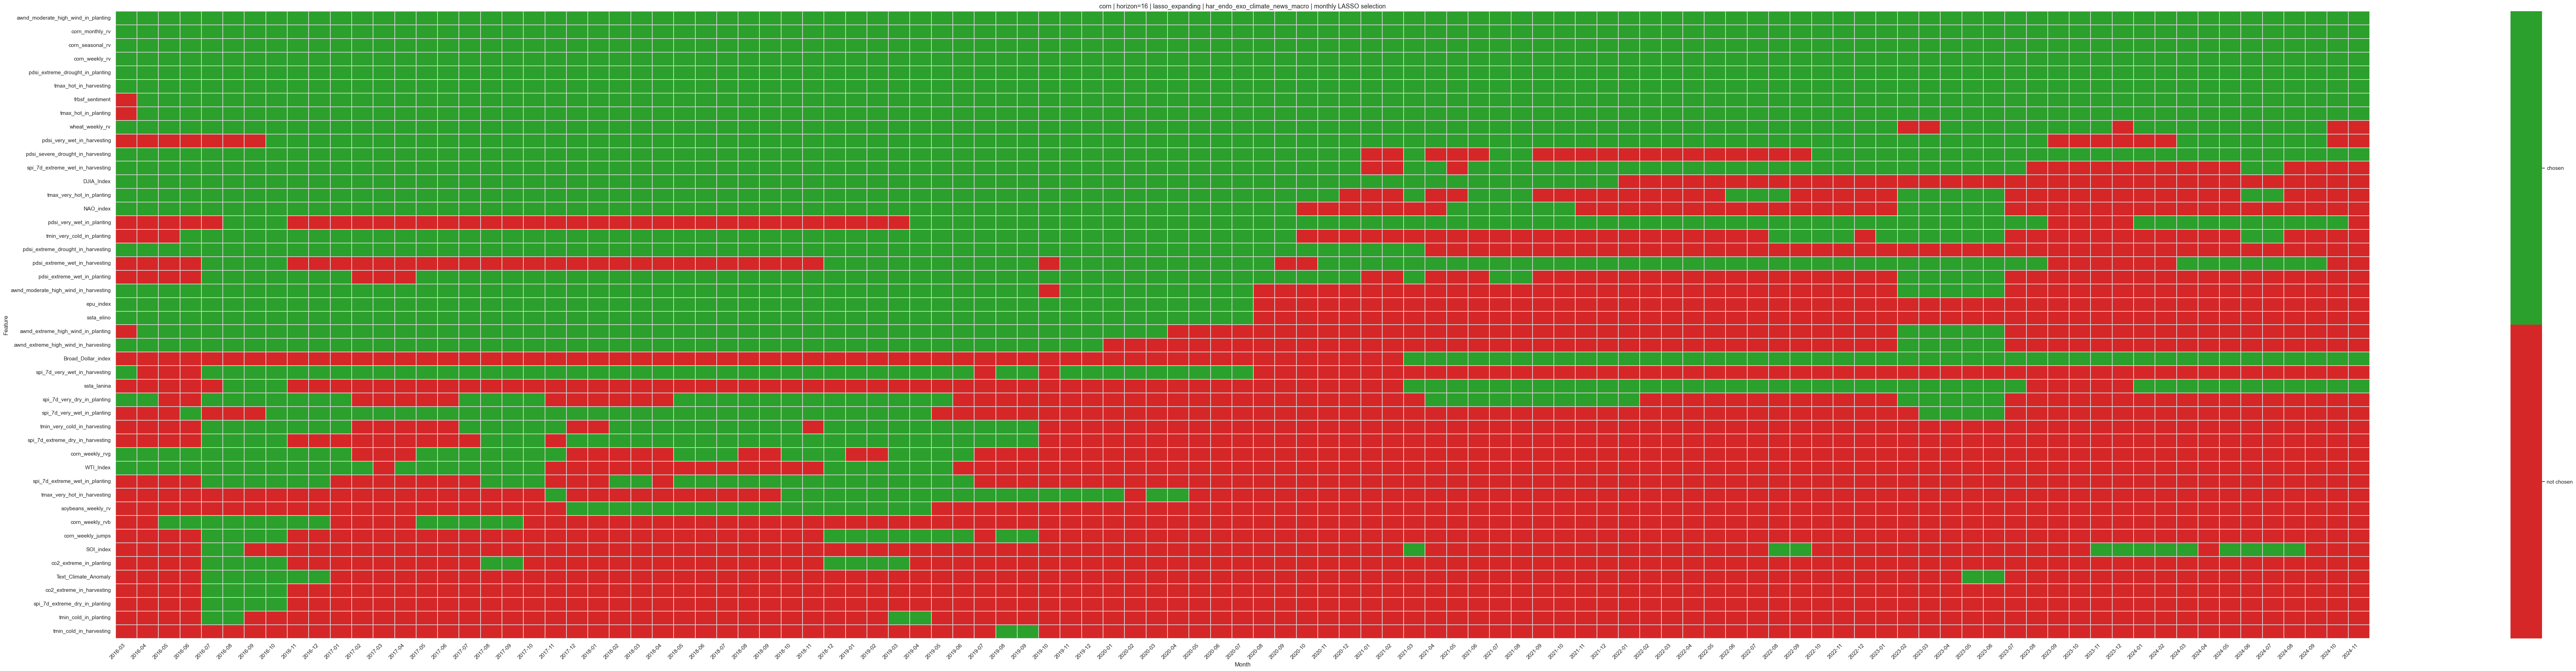

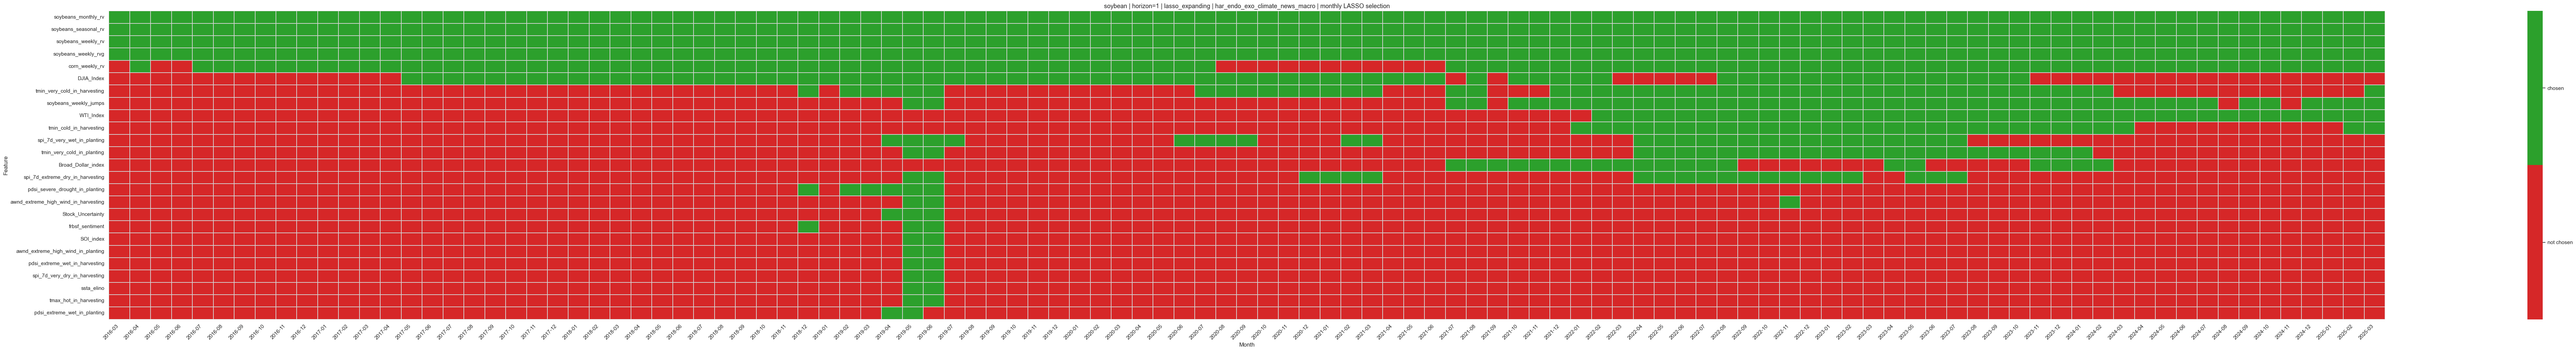

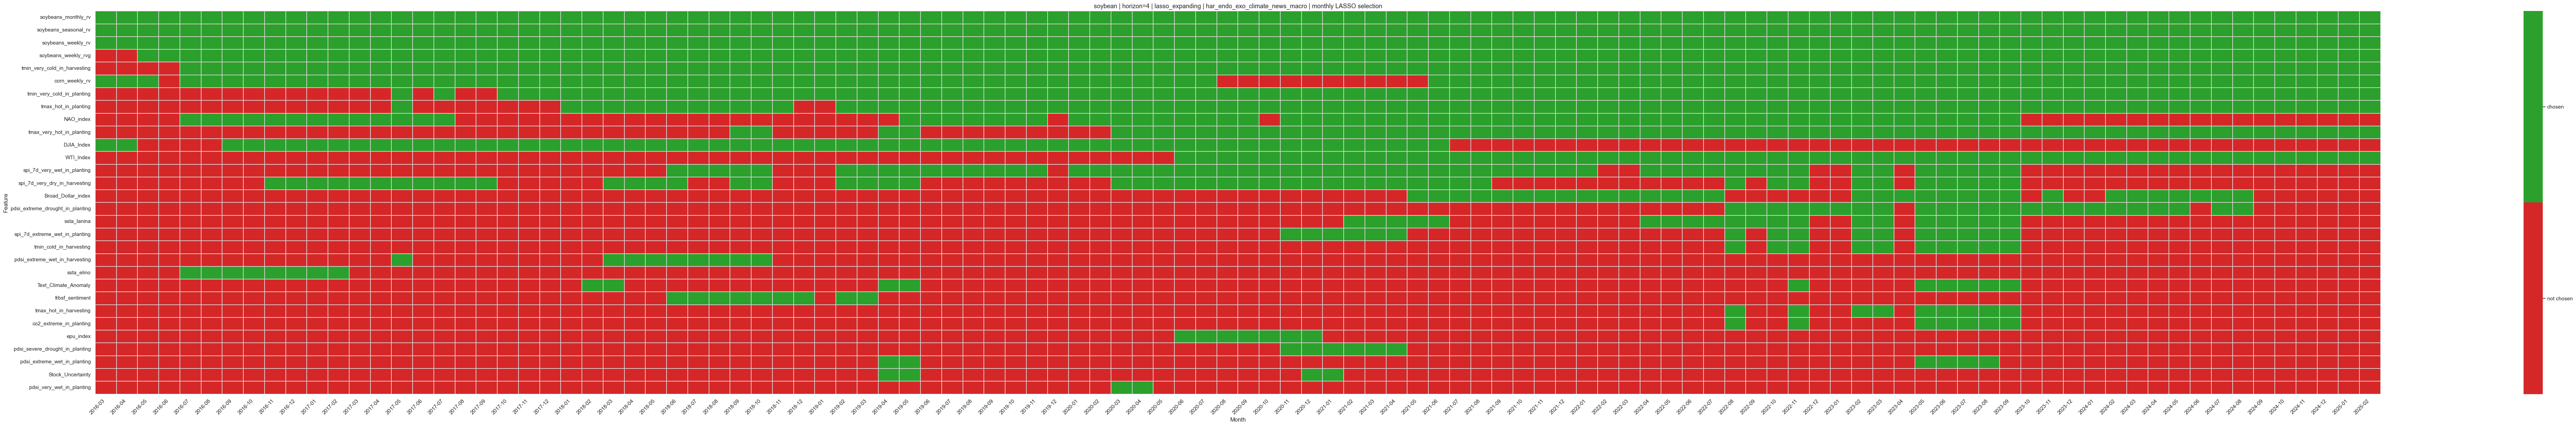

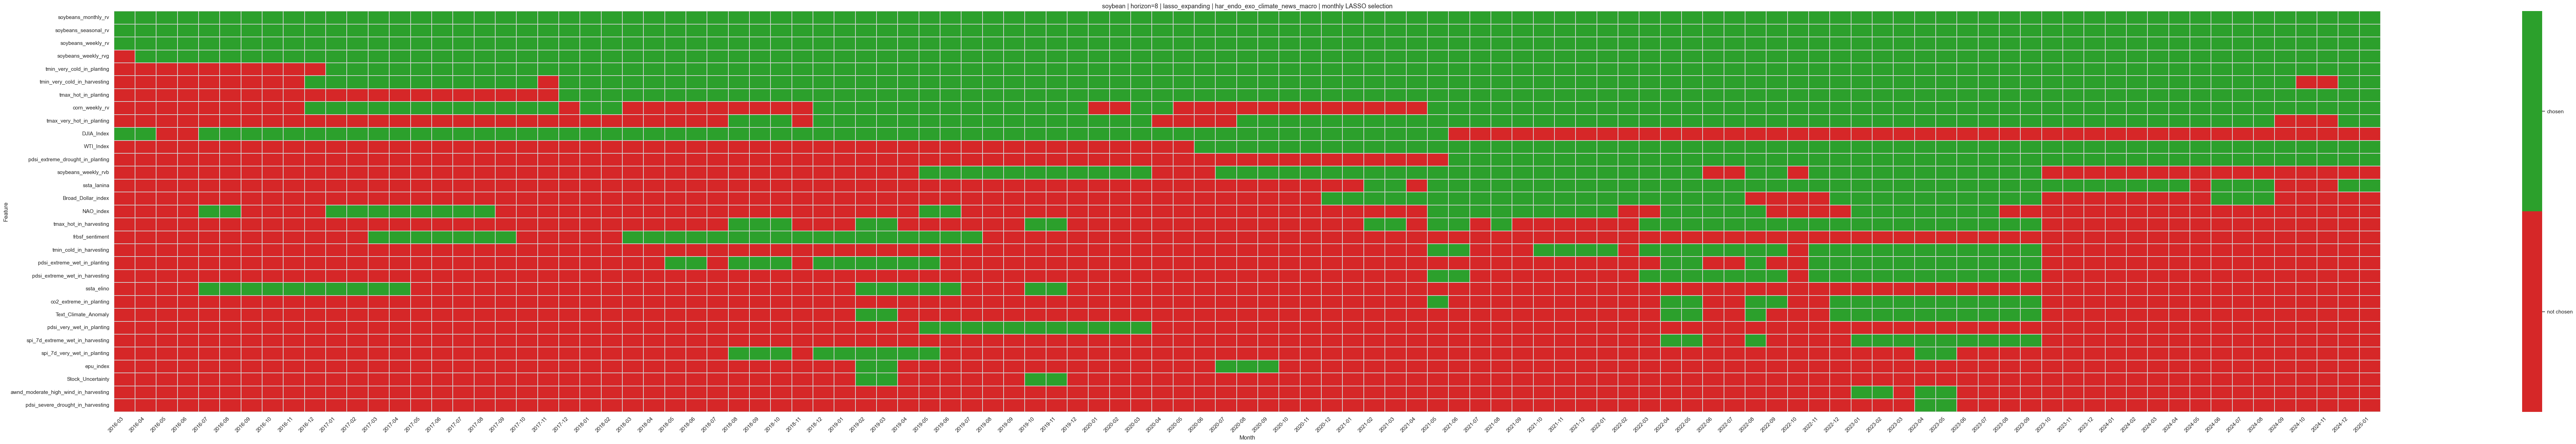

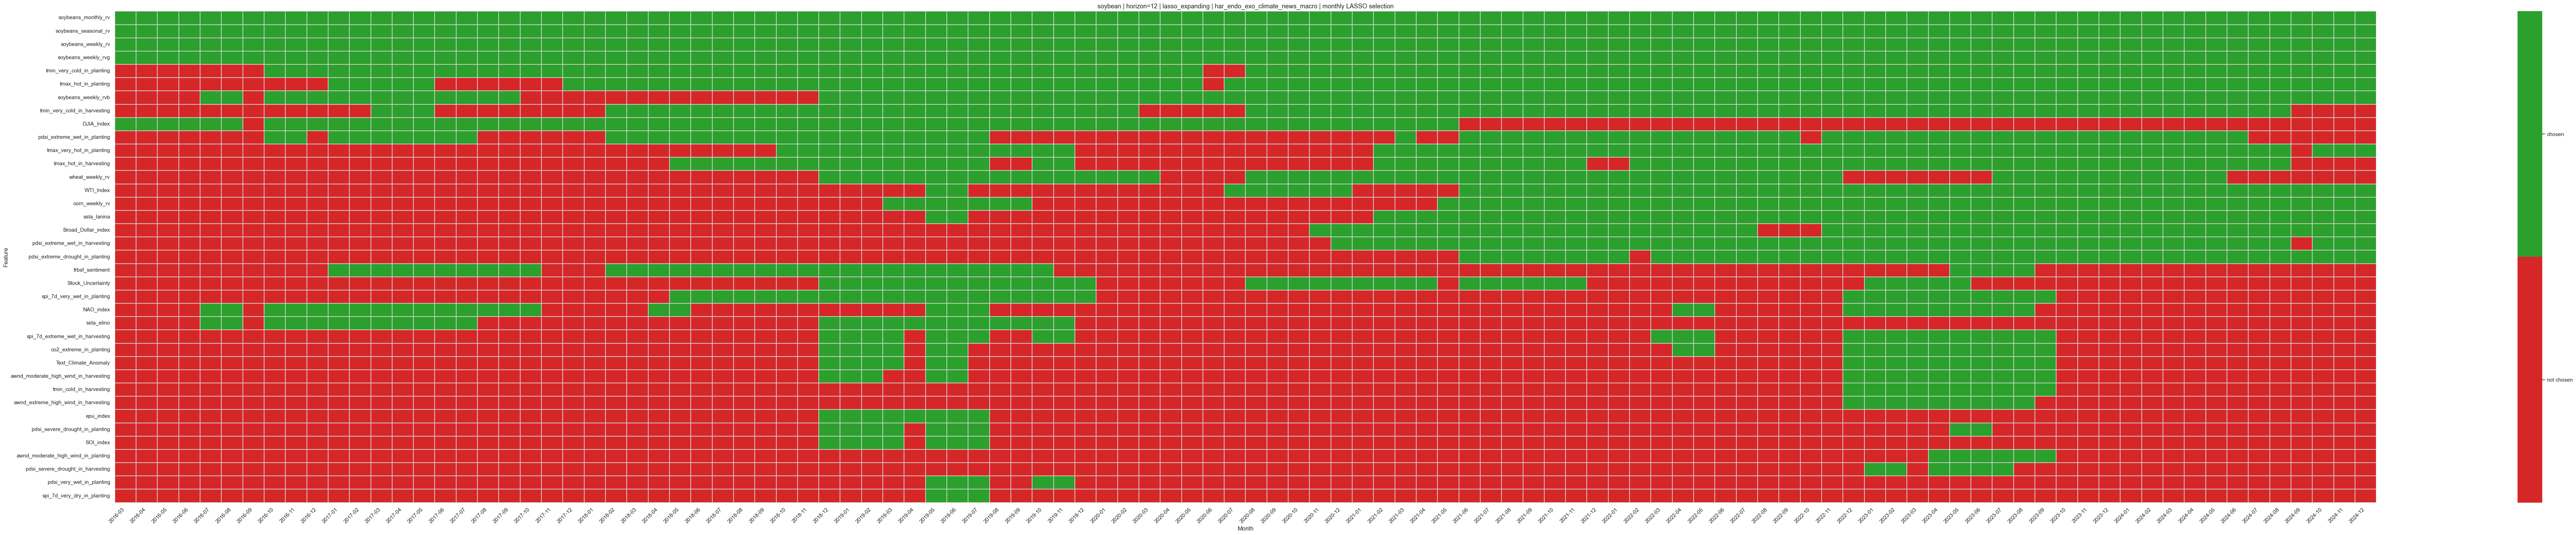

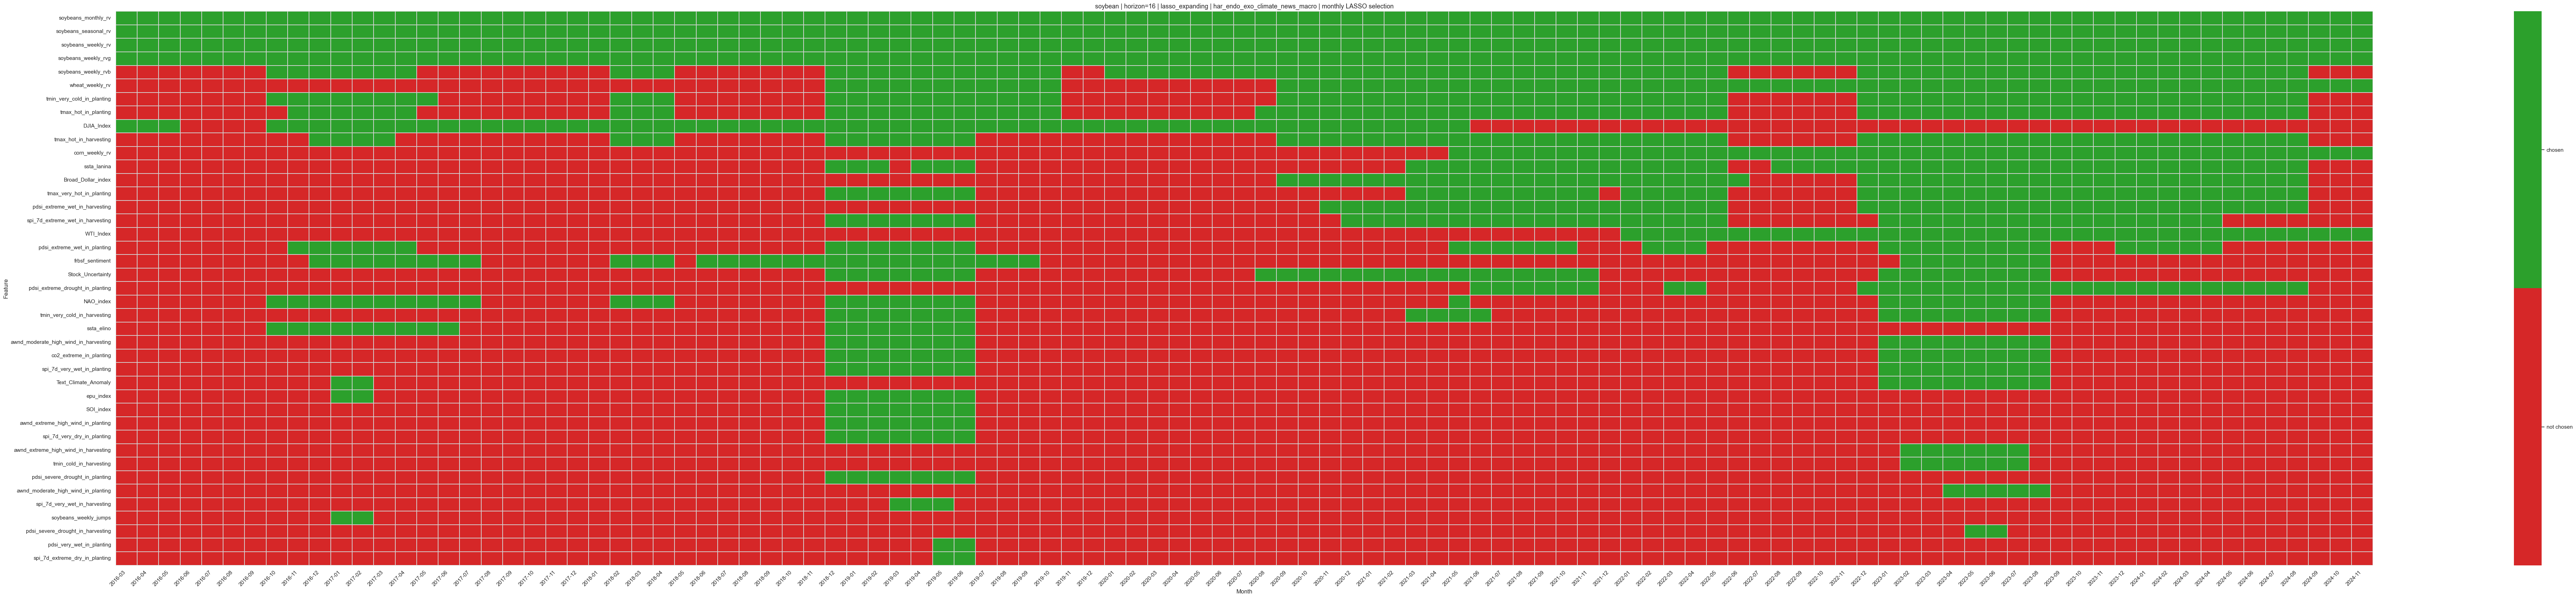

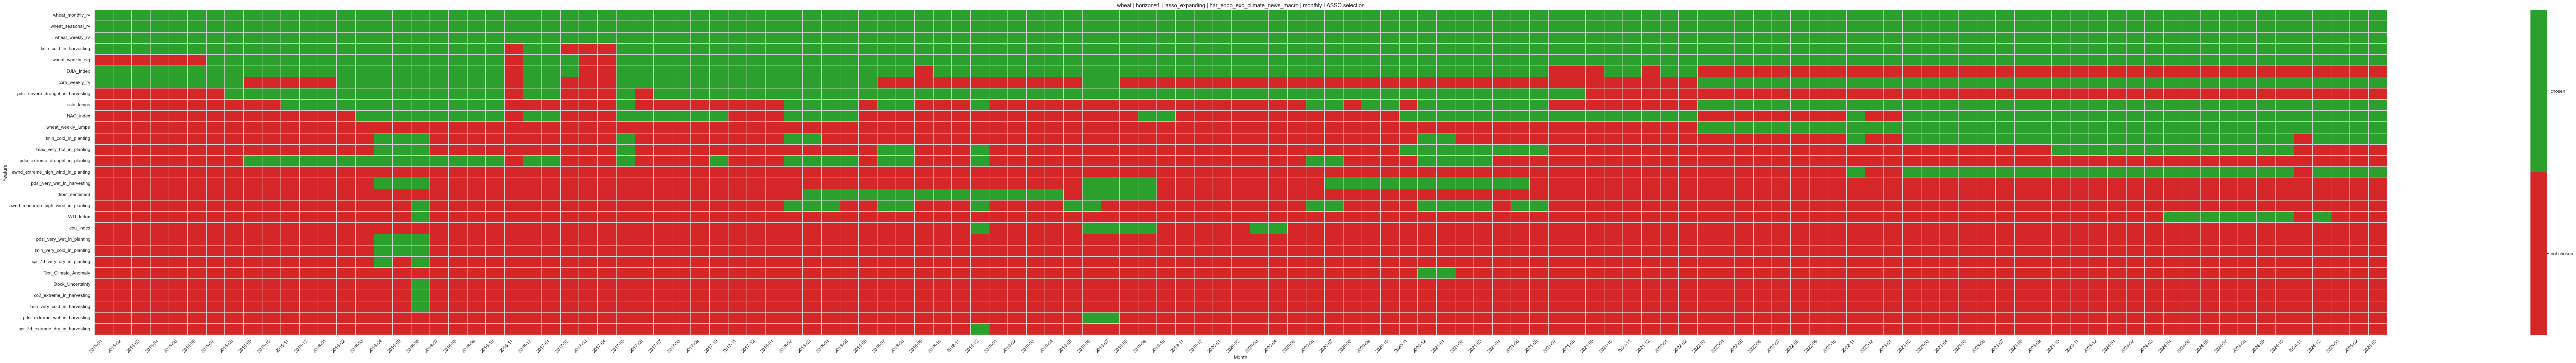

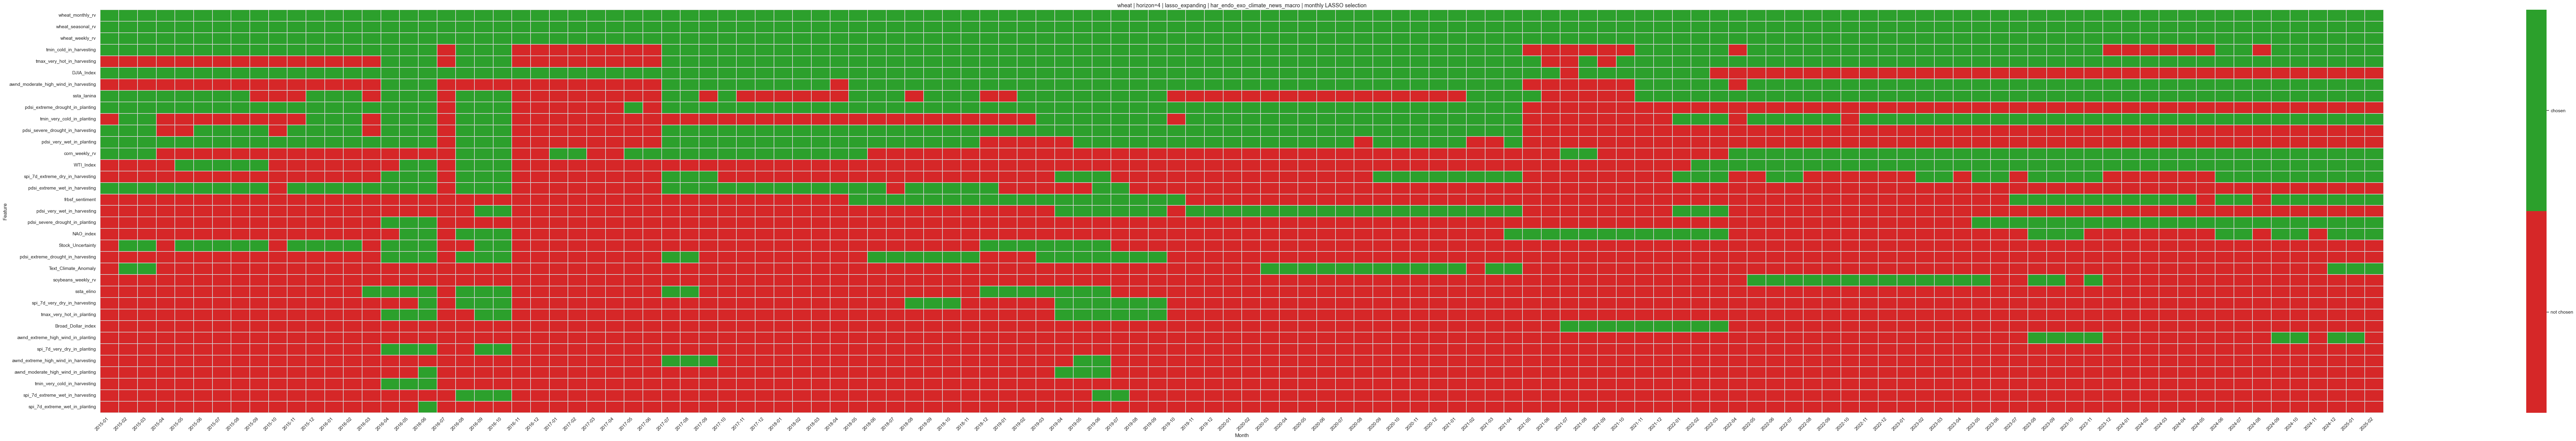

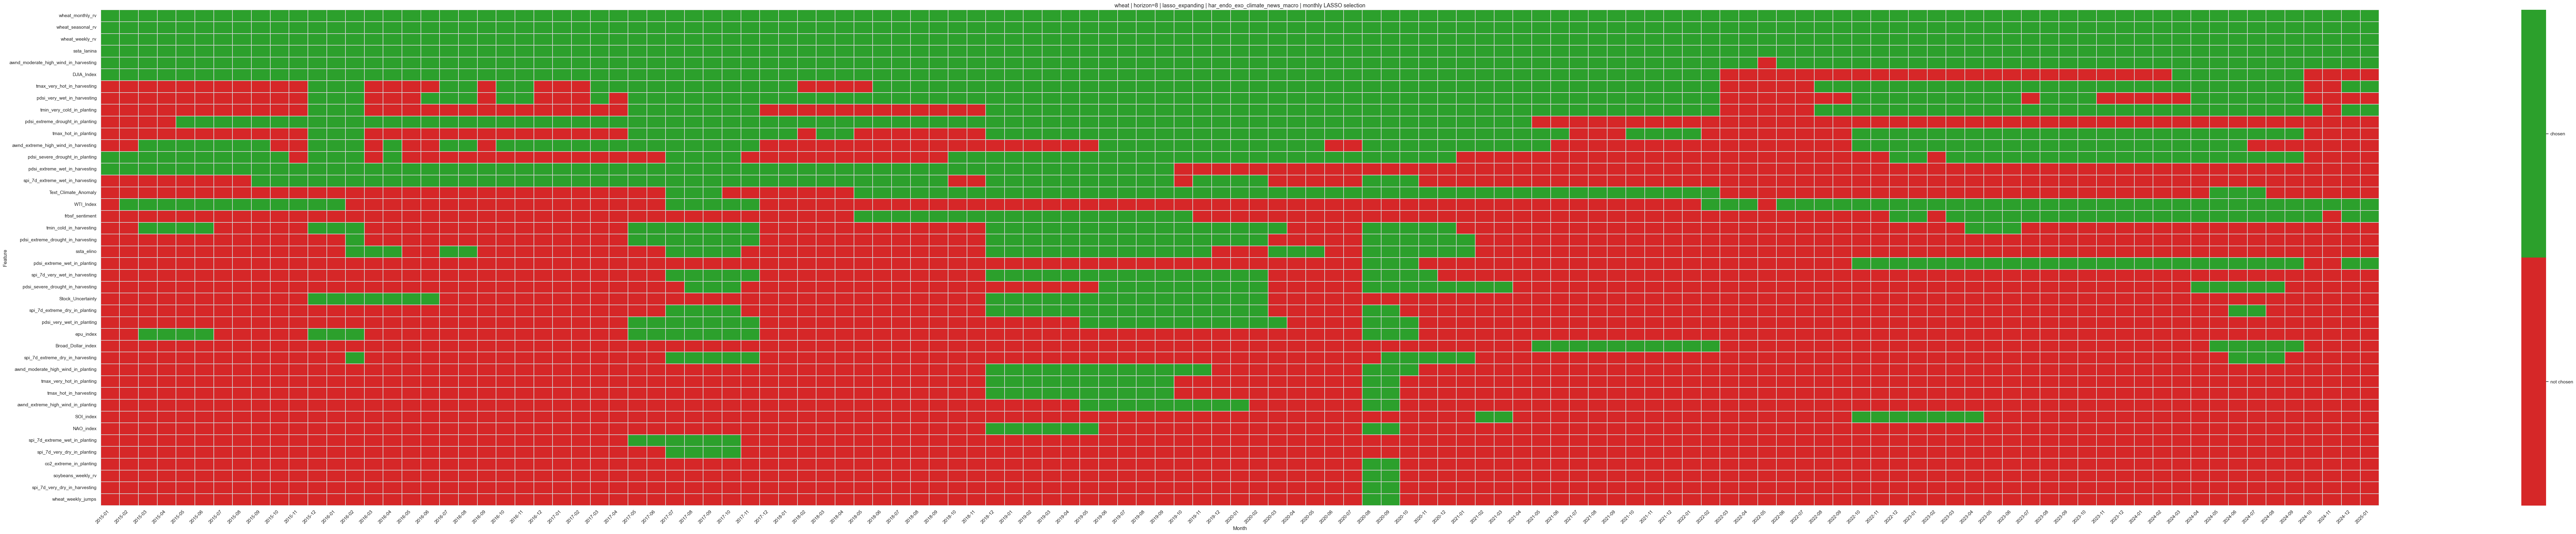

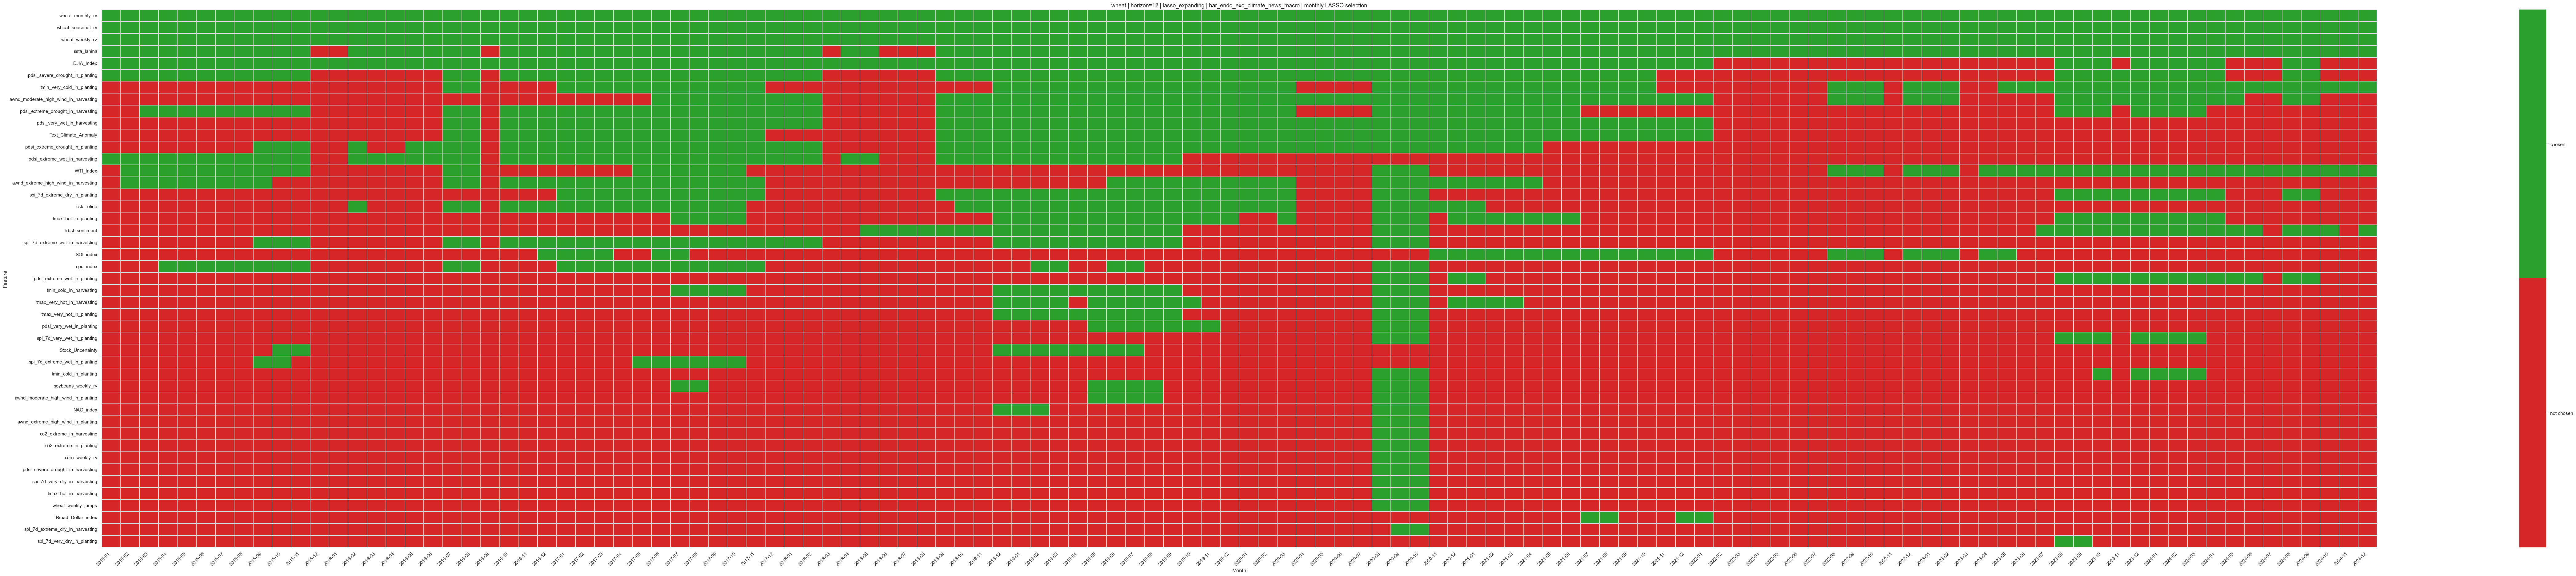

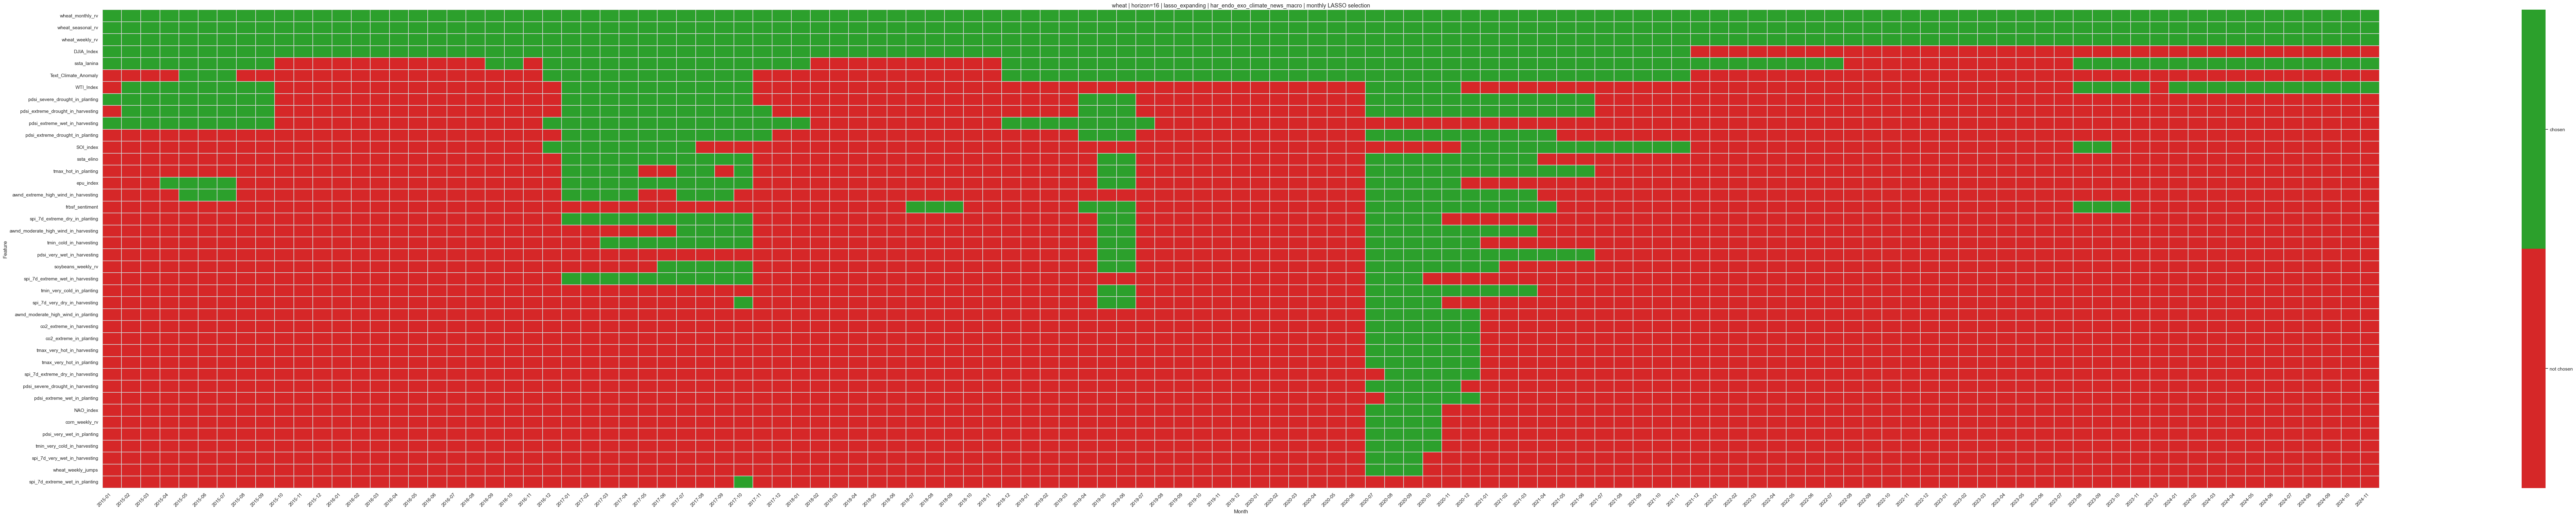

Successful runs: 15
Failed runs: 0


,crop,target_horizon,model_type,feature_set,checkpoint_dir,plot_path,n_features,n_months,selection_method
0,corn,1,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,37,109,lasso
1,corn,4,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,40,108,lasso
2,corn,8,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,44,107,lasso
3,corn,12,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,46,106,lasso
4,corn,16,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,46,105,lasso
5,soybean,1,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,25,109,lasso
6,soybean,4,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,30,108,lasso
7,soybean,8,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,31,107,lasso
8,soybean,12,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,37,106,lasso
9,soybean,16,lasso_expanding,har_endo_exo_climate_news_macro,/Users/arshia/Projects/Papers/FinancialAI/Volf...,/Users/arshia/Projects/Papers/FinancialAI/Volf...,41,105,lasso


In [8]:
batch_results: list[dict] = []
failed_runs: list[dict] = []
preview_limit = 3

for idx, (_, row) in enumerate(runs_to_process.iterrows(), start=1):
    crop = str(row['crop'])
    horizon = int(row['target_horizon'])
    model_type = str(row['model_type'])
    feature_set = str(row['feature_set'])
    run_slug = f"{safe_name(model_type)}__{safe_name(feature_set)}"
    title = f"{crop} | horizon={horizon} | {model_type} | {feature_set} | monthly LASSO selection"

    try:
        checkpoint_dir, per_window_df, selection_info = load_selection_artifacts(BENCHMARK_ROOT, row)
        selection_daily_df = explode_selection_by_day(per_window_df)
        monthly_df = aggregate_selection_by_month(selection_daily_df)

        run_output_dir = OUTPUT_ROOT / crop / f'target_horizon_{horizon}' / run_slug
        plot_path = run_output_dir / 'feature_selection_monthly_heatmap.png'

        feature_summary = (
            monthly_df.groupby('feature', as_index=False)
            .agg(
                selected_months=('selected', 'sum'),
                total_months=('selected', 'size'),
                average_selected_share=('selected_share', 'mean'),
            )
            .sort_values(['average_selected_share', 'selected_months', 'feature'], ascending=[False, False, True])
            .reset_index(drop=True)
        )

        if SAVE_PLOTS:
            _ = plot_monthly_feature_selection(
                monthly_df,
                title=title,
                output_path=plot_path,
                top_n_features=TOP_N_FEATURES,
            )

        batch_results.append(
            {
                'crop': crop,
                'target_horizon': horizon,
                'model_type': model_type,
                'feature_set': feature_set,
                'checkpoint_dir': str(checkpoint_dir),
                'plot_path': str(plot_path) if SAVE_PLOTS else None,
                'n_features': monthly_df['feature'].nunique(),
                'n_months': monthly_df['month'].nunique(),
                'selection_method': selection_info.get('method'),
            }
        )

        if idx <= preview_limit:
            display(feature_summary.head(10))
    except Exception as exc:
        failed_runs.append(
            {
                'crop': crop,
                'target_horizon': horizon,
                'model_type': model_type,
                'feature_set': feature_set,
                'error': str(exc),
            }
        )

results_df = pd.DataFrame(batch_results).sort_values(['crop', 'target_horizon', 'model_type', 'feature_set']).reset_index(drop=True)
failed_df = pd.DataFrame(failed_runs)

print(f'Successful runs: {len(results_df):,}')
print(f'Failed runs: {len(failed_df):,}')
display(results_df.head(20))
if not failed_df.empty:
    display(failed_df)


In [9]:
manifest_path = OUTPUT_ROOT / 'lasso_feature_selection_monthly_manifest.csv'
results_df.to_csv(manifest_path, index=False)
print(f'Saved manifest: {manifest_path}')


Saved manifest: /Users/arshia/Projects/Papers/FinancialAI/Volf/data/benchmark/plots/feature_selection_monthly/lasso_feature_selection_monthly_manifest.csv


## Output files

For each available crop / horizon run, the notebook saves:
- `feature_selection_monthly_heatmap.png`

It also saves one batch manifest:
- `data/benchmark/plots/feature_selection_monthly/lasso_feature_selection_monthly_manifest.csv`
